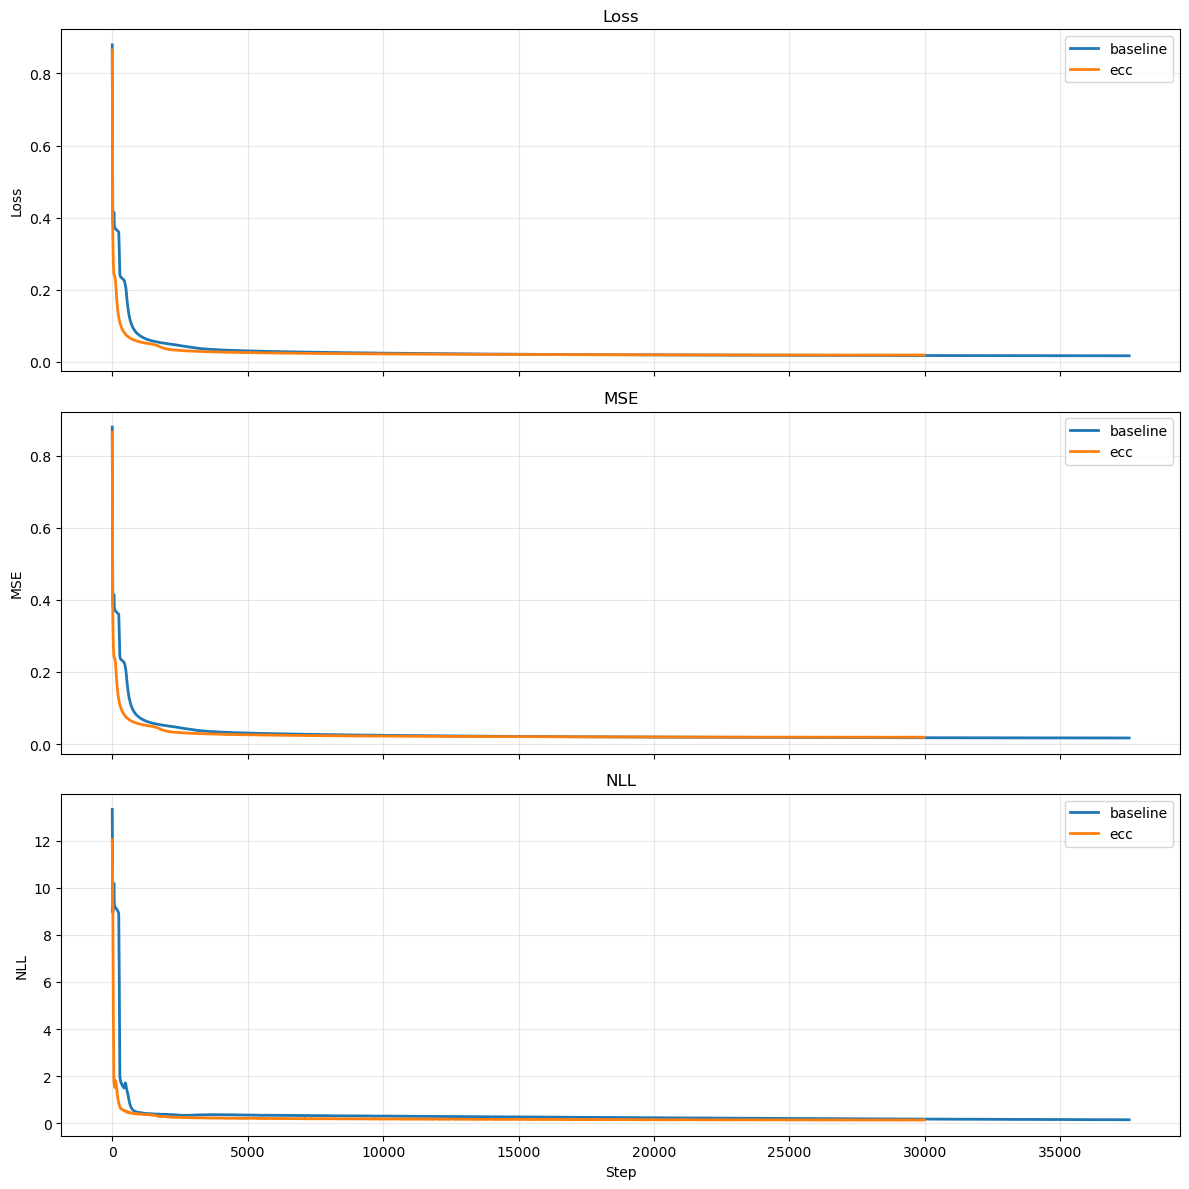

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

baseline_path = "progress_baseline.csv"
ecc_path = "diffusion_models/diffuseq_qqp_h128_lr0.0001_t2000_sqrt_lossaware_seed102_qqp20260422-17:21:27/progress.csv"

baseline = pd.read_csv(baseline_path)
ecc = pd.read_csv(ecc_path)

baseline_train = baseline[baseline["step"].notna()].copy()
ecc_train = ecc[ecc["step"].notna()].copy()

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Loss
axes[0].plot(baseline_train["step"], baseline_train["loss"], label="baseline", linewidth=2)
axes[0].plot(ecc_train["step"], ecc_train["loss"], label="ecc", linewidth=2)
axes[0].set_title("Loss")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# MSE
axes[1].plot(baseline_train["step"], baseline_train["mse"], label="baseline", linewidth=2)
axes[1].plot(ecc_train["step"], ecc_train["mse"], label="ecc", linewidth=2)
axes[1].set_title("MSE")
axes[1].set_ylabel("MSE")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# NLL
axes[2].plot(baseline_train["step"], baseline_train["nll"], label="baseline", linewidth=2)
axes[2].plot(ecc_train["step"], ecc_train["nll"], label="ecc", linewidth=2)
axes[2].set_title("NLL")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("NLL")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


Matched sequence ids: 20


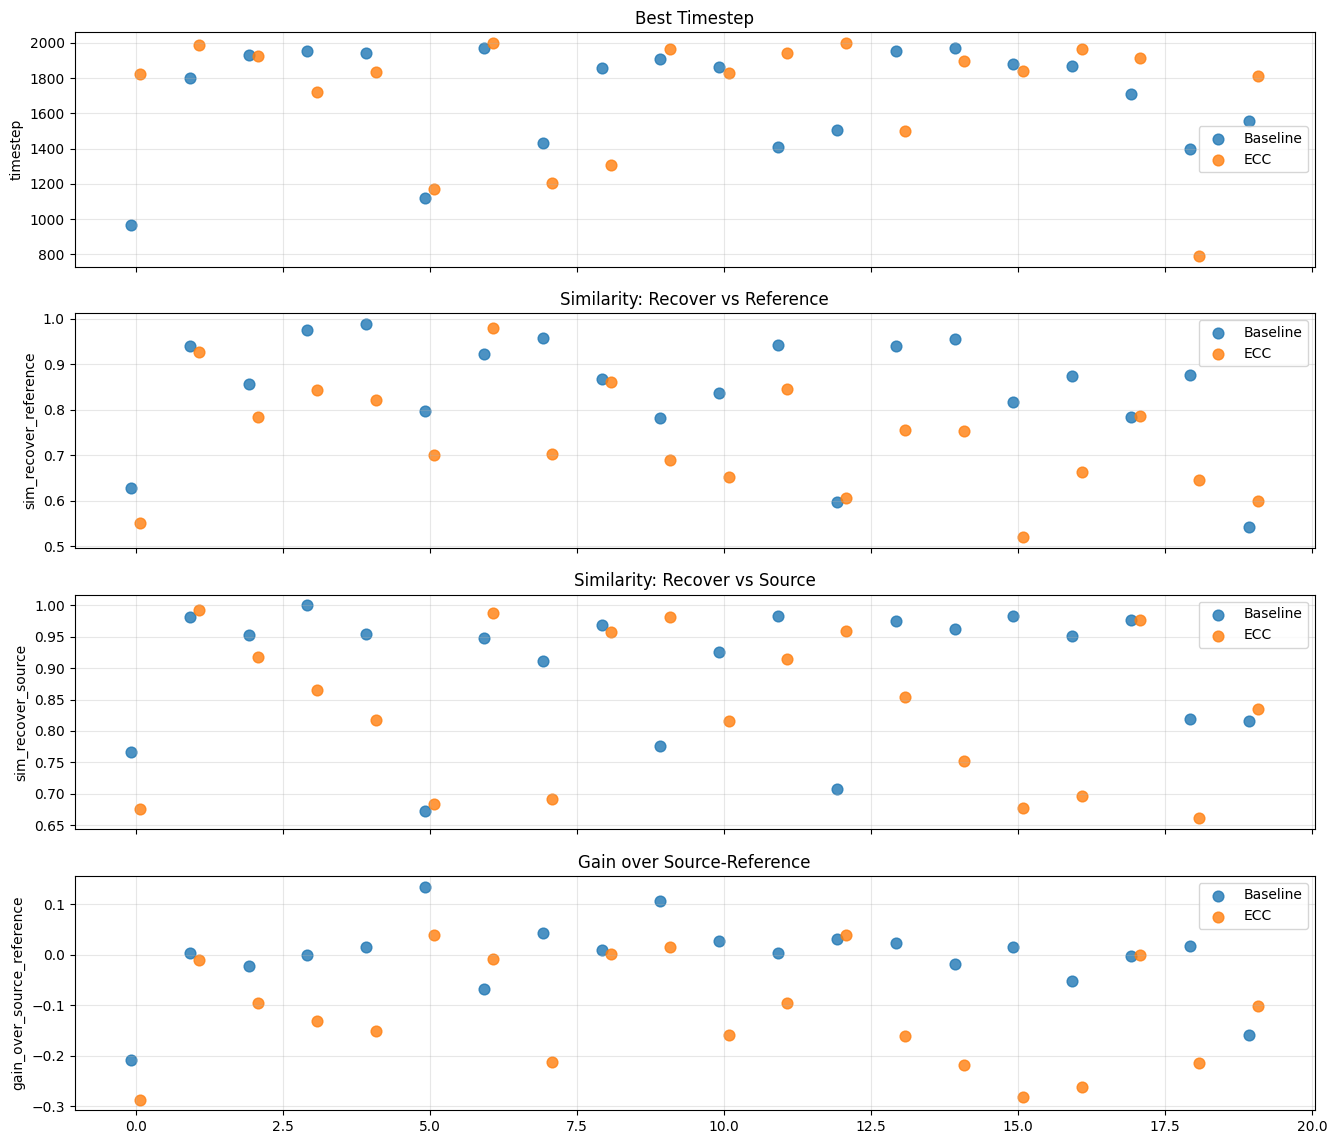

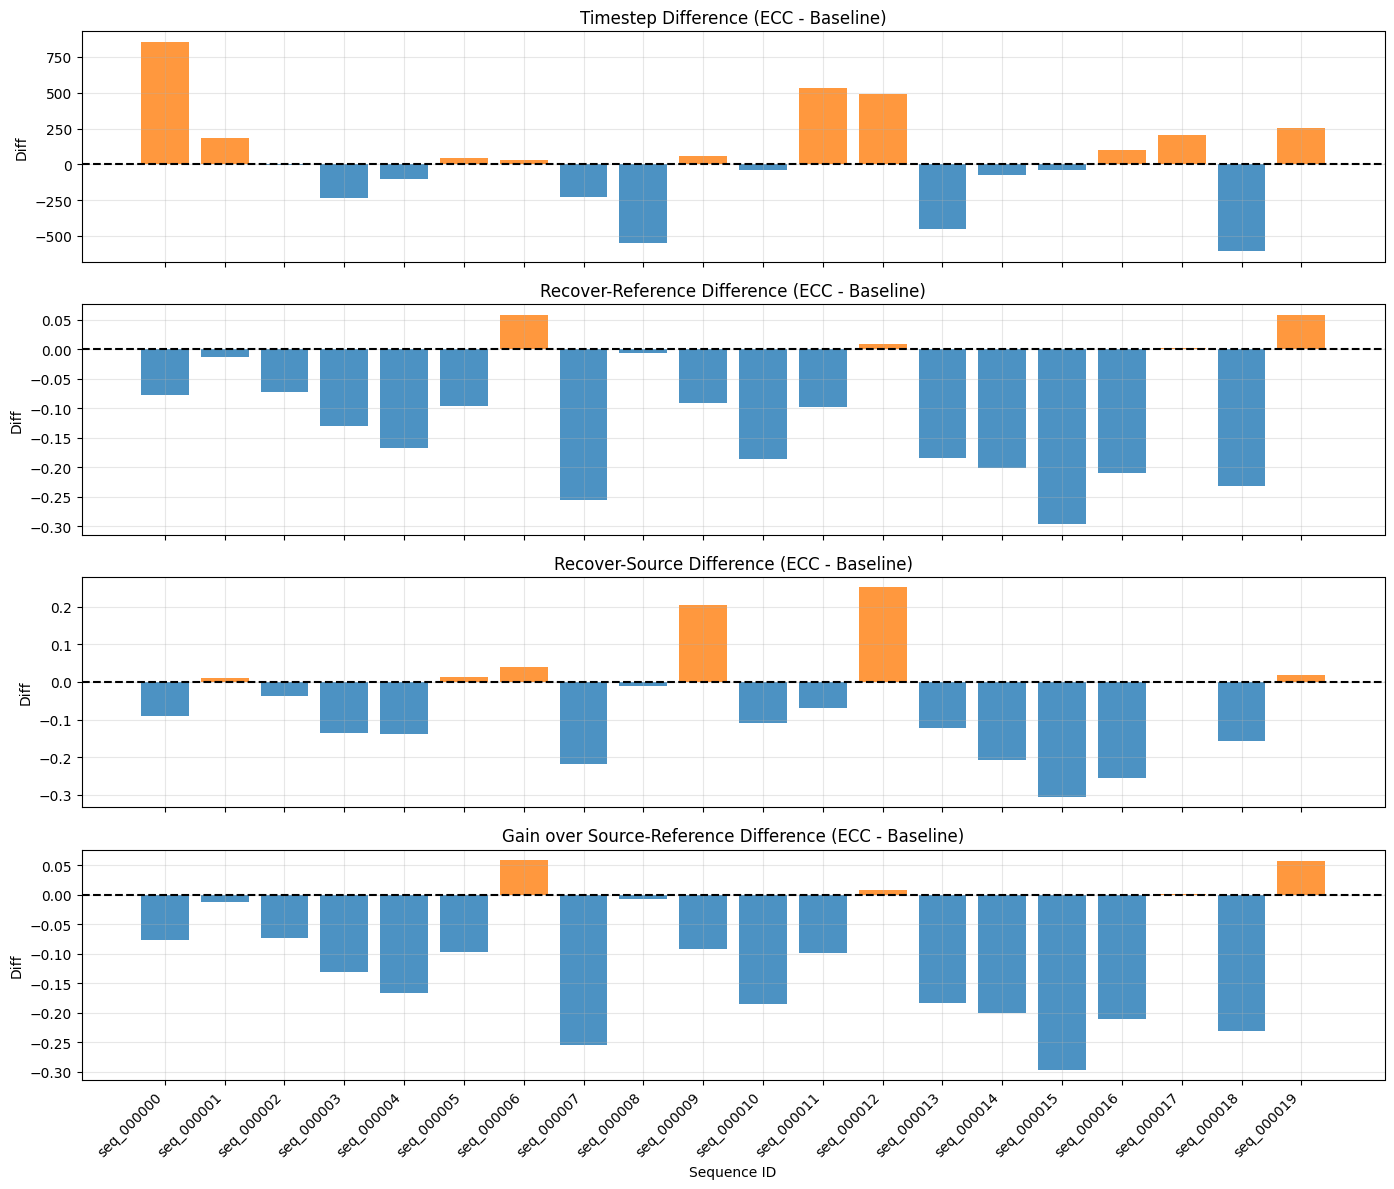

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

baseline = pd.read_parquet("best_recovery_by_sequence_baseline.parquet", engine="pyarrow")
ecc = pd.read_parquet("best_recovery_by_sequence_ecc.parquet", engine="pyarrow")

# Merge same sample from both models
df = baseline.merge(
    ecc,
    on="sequence_id",
    suffixes=("_baseline", "_ecc"),
    how="inner",
    validate="one_to_one",
)

# If you want exactly 20 samples
df = df.sort_values("sequence_id").reset_index(drop=True)
print("Matched sequence ids:", len(df))
# assert len(df) == 20

x = np.arange(len(df))
xlabels = df["sequence_id"].astype(str)

metrics = [
    ("timestep", "Best Timestep"),
    ("sim_recover_reference", "Similarity: Recover vs Reference"),
    ("sim_recover_source", "Similarity: Recover vs Source"),
    ("gain_over_source_reference", "Gain over Source-Reference"),
]

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

for ax, (metric, title) in zip(axes, metrics):
    ax.scatter(
        x - 0.08,
        df[f"{metric}_baseline"],
        color="tab:blue",
        s=60,
        alpha=0.8,
        label="Baseline",
    )
    ax.scatter(
        x + 0.08,
        df[f"{metric}_ecc"],
        color="tab:orange",
        s=60,
        alpha=0.8,
        label="ECC",
    )
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    ax.legend()
import matplotlib.pyplot as plt

metrics = [
    ("timestep", "Timestep"),
    ("sim_recover_reference", "Recover-Reference"),
    ("sim_recover_source", "Recover-Source"),
    ("gain_over_source_reference", "Gain over Source-Reference"),
]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

x = range(len(df))

for ax, (metric, title) in zip(axes, metrics):
    diff = df[f"{metric}_ecc"] - df[f"{metric}_baseline"]
    colors = ["tab:orange" if v > 0 else "tab:blue" for v in diff]
    ax.bar(x, diff, color=colors, alpha=0.8)
    ax.axhline(0, color="black", linestyle="--")
    ax.set_title(f"{title} Difference (ECC - Baseline)")
    ax.set_ylabel("Diff")
    ax.grid(True, alpha=0.3)

axes[-1].set_xticks(range(len(df)))
axes[-1].set_xticklabels(df["sequence_id"].astype(str), rotation=45, ha="right")
axes[-1].set_xlabel("Sequence ID")

plt.tight_layout()
plt.show()


In [6]:
metrics = [
    "timestep",
    "sim_recover_reference",
    "sim_recover_source",
    "gain_over_source_reference",
]

for metric in metrics:
    b = df[f"{metric}_baseline"]
    e = df[f"{metric}_ecc"]
    d = e - b

    print(f"\n=== {metric} ===")
    print(f"Baseline mean: {b.mean():.4f}")
    print(f"ECC mean:      {e.mean():.4f}")
    print(f"Mean diff:     {d.mean():.4f}   (ECC - Baseline)")
    print(f"Median diff:   {d.median():.4f}")
    print(f"ECC wins:      {(d > 0).sum()} / {len(d)}")
    print(f"Baseline wins: {(d < 0).sum()} / {len(d)}")
    print(f"Ties:          {(d == 0).sum()} / {len(d)}")



=== timestep ===
Baseline mean: 1699.5500
ECC mean:      1721.0000
Mean diff:     21.4500   (ECC - Baseline)
Median diff:   11.0000
ECC wins:      10 / 20
Baseline wins: 10 / 20
Ties:          0 / 20

=== sim_recover_reference ===
Baseline mean: 0.8439
ECC mean:      0.7343
Mean diff:     -0.1096   (ECC - Baseline)
Median diff:   -0.0974
ECC wins:      4 / 20
Baseline wins: 16 / 20
Ties:          0 / 20

=== sim_recover_source ===
Baseline mean: 0.9017
ECC mean:      0.8357
Mean diff:     -0.0660   (ECC - Baseline)
Median diff:   -0.0799
ECC wins:      6 / 20
Baseline wins: 14 / 20
Ties:          0 / 20

=== gain_over_source_reference ===
Baseline mean: -0.0051
ECC mean:      -0.1147
Mean diff:     -0.1096   (ECC - Baseline)
Median diff:   -0.0973
ECC wins:      4 / 20
Baseline wins: 16 / 20
Ties:          0 / 20
